# Logfile check
Use this notebook for an in depth look at a selected data session from the VR acquisition system.
Can be used to look for weirdness in the data and debug the experimental setup.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('../'))
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
import tifffile
import glob
from tqdm import tqdm
import numpy as np
import logreader.logreader as lr

In [2]:
#PARAMETERS
animal = '441406_fiano'
animal_num = animal.split('_')[0]
date = '20230323'


session_path = Path(f'/ceph/imaging1/arie/{animal}/{date}_{animal_num}')
#save_path =  Path(f'/ceph/imaging1/davide/2p_data/{animal}/{date}')

tif_file = glob.glob(str(session_path)+'/*.tif')[0]
log_file = glob.glob(str(session_path)+'/*.b64')[0]

print(log_file)
print(tif_file)

/ceph/imaging1/arie/441406_fiano/20230323_441406/20230323-105059_533.b64
/ceph/imaging1/arie/441406_fiano/20230323_441406/20230323_441406_00001.tif


# Decode session log and tif header

In [3]:
vr_data = lr.preprocess_vr_data(tif_file = tif_file ,log_file=log_file)

Decoding log file


  0%|          | 0/1941576 [00:00<?, ?it/s]

0it [00:00, ?it/s]

In [4]:
decoded_log = lr.create_bp_structure(log_file)

Decoding log file


  0%|          | 0/1941576 [00:00<?, ?it/s]

In [5]:
tif_header = lr.read_tif_header(tif_file)

0it [00:00, ?it/s]

In [7]:
frames = tif_header['frame_ts']
i2c_data =tif_header['i2c_data']

In [8]:
digital_in = decoded_log['digitalIn'].astype(int)
digital_out = decoded_log['digitalOut'].astype(int)
scanner_digital = digital_in[:,6]
log_times = decoded_log['startTS'].astype(float)
barcode = digital_out[:,4]

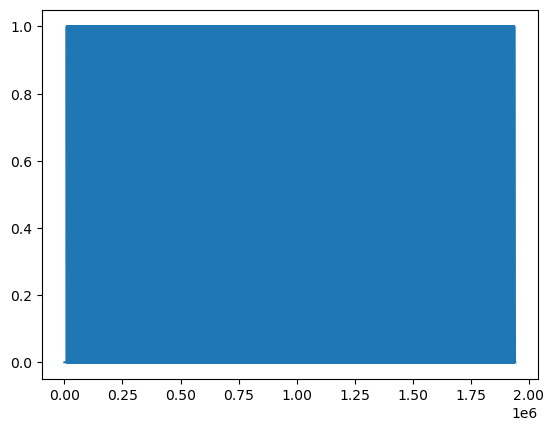

In [8]:
plt.plot(scanner_digital)

In [9]:
lr.compute_sync_shift(scanner_digital,log_times,frames)

21.580929093010003

In [10]:
tm = lr.build_trial_matrix(digital_in,digital_out)

In [13]:
tm

,env_onset,tunnel1_onset,reward_zone_onset,tunnel2_onset,tunnel2_offset,trial_duration,env_label,sound_onset,sound_offset,sound_presented,reward_onset,reward_offset
0,0.0,50658,53576,79380,81541.0,NaN,1,NaN,NaN,False,54256,56273
1,81541.0,89293,91834,105453,107834.0,NaN,1,NaN,NaN,False,93054,95060
2,107834.0,115345,117787,146503,149747.0,NaN,2,109836.0,112752.0,True,118929,120938
3,149747.0,156242,158962,179704,182337.0,NaN,3,151702.0,154702.0,True,159502,161517
4,182337.0,193470,196151,219033,222034.0,NaN,1,186661.0,189675.0,True,198056,200065
5,222034.0,236324,239044,257345,259524.0,NaN,2,NaN,NaN,False,240015,242031
6,259524.0,267780,270385,335202,338616.0,NaN,3,261008.0,264021.0,True,270961,272991
7,338616.0,347565,357260,381541,383838.0,NaN,2,340948.0,343968.0,True,358311,360327
8,383838.0,393451,402117,423495,427127.0,NaN,1,NaN,NaN,False,403501,405524
9,427127.0,433882,436439,478496,480867.0,NaN,3,428915.0,431922.0,True,438687,440706


# Arrange and plot chanel data

In [11]:
for k in decoded_log.keys():
    print(f'{k}: {decoded_log[k].shape}')

analog: (1941576, 8)
digitalIn: (1941576, 16)
digitalOut: (1941576, 8)
startTS: (1941576,)
transmitTS: (1941576,)
longVar: (1941576, 8)
packetNums: (1941576,)


In [12]:
labels_in = ['empty','empty','wheelA','wheelB','wheelC','IR_camera','scanner','sound','unknown','reward_zone','environment1',
             'environment2','environment3_broken','tunnel1','tunnel2','environment3']
labels_out = ['valve','empty','IR_lED_sync','empty','barcode','IR_LED','lick','empty']

In [11]:
digital_in = decoded_log['digitalIn'].astype(int)
digital_out = decoded_log['digitalOut'].astype(int)
digital_scan_signal = digital_in[:,6]
log_times = decoded_log['startTS']
#sync_times = lr.compute_sync_times(digital_scan_signal,log_times,frames)

In [23]:
print (onsets)
len (onsets)

[  23235   33388   70986   94991  110524  136908  150282  192765  218429
  282801  341378  369260  387409  403975  422433  440117  458728  471911
  490988  503393  537553  588894  634510  657362  670966  683617  705375
  732329  759409  773836  801366  814751  837914  861939  901669  927427
  942834  977798 1035292 1051247 1070309 1117962 1153051 1168807 1192116
 1208824 1229617 1278743 1300519 1340771 1371875 1416473 1431930 1449775
 1464829 1496071 1513888 1533477 1564107 1585561 1604258 1621018 1662220
 1686364 1709839 1738418 1760480 1775927 1793481 1835115 1856424 1880729
 1905415 1921154]


74

In [20]:
print (offsets)
len(offsets)

[  30379   68393   91974  108141  133909  147276  189746  215423  279775
  339052  366245  384403  400952  419411  437108  456512  469247  488343
  500374  534544  586943  631506  654683  667958  680607  702368  729310
  756394  770813  799102  811729  835225  858928  898666  924419  940161
  974794 1032278 1048302 1067287 1114950 1150176 1165789 1189563 1205820
 1227098 1276384 1297491 1337748 1368852 1413977 1429563 1446752 1461814
 1493070 1510873 1530661 1561690 1582544 1602172 1617992 1659199 1683354
 1706838 1735411 1757880 1773362 1790504 1832107 1853422 1877716 1902391
 1918130]


73

In [25]:
channel = 7
# plt.figure(figsize=(20,10))
x = digital_in[:,channel]
# plt.plot(x)
onsets = lr.compute_onsets(x)
offsets = lr.compute_offsets(x)
#plt.eventplot(onsets,color='r')
print(len(onsets))
# plt.xlabel('time (logifle units)')
print(offsets[1:]-onsets)
#plt.title(f'Average time on {np.mean(digital_in[34000:34010,channel]):.3f}')

74


ValueError: operands could not be broadcast together with shapes (72,) (74,) 

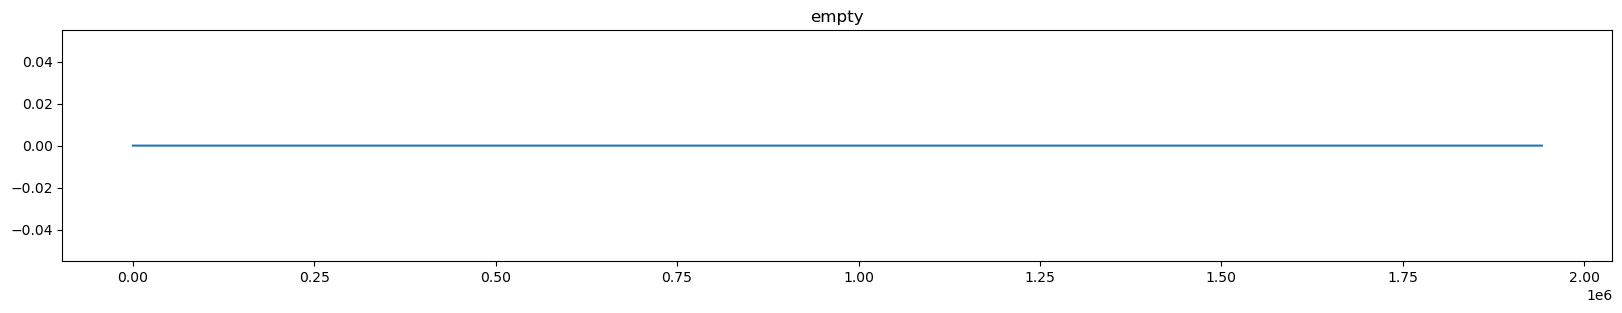

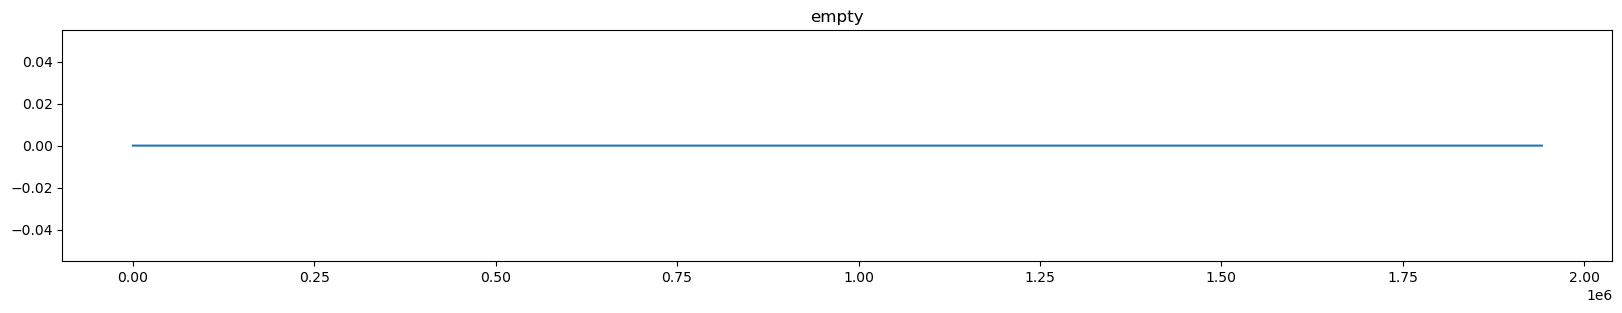

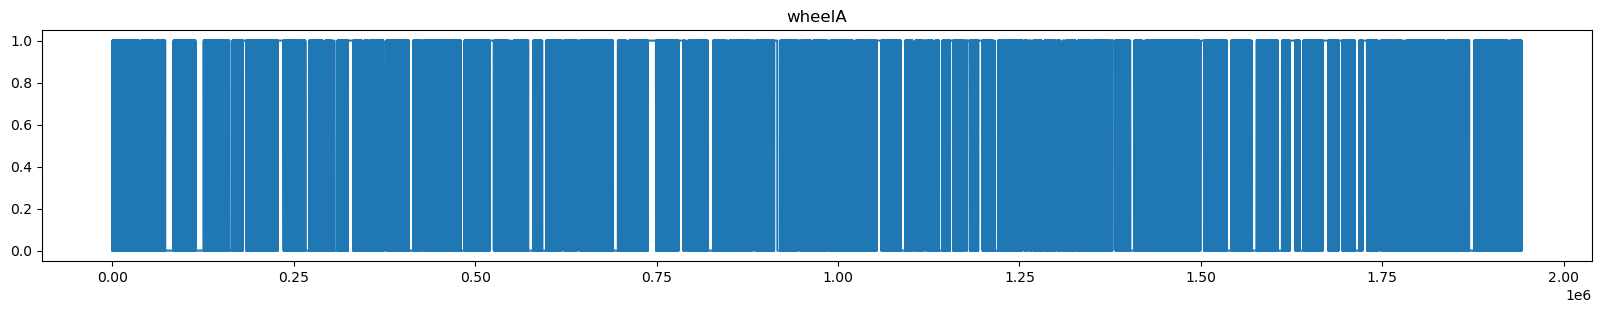

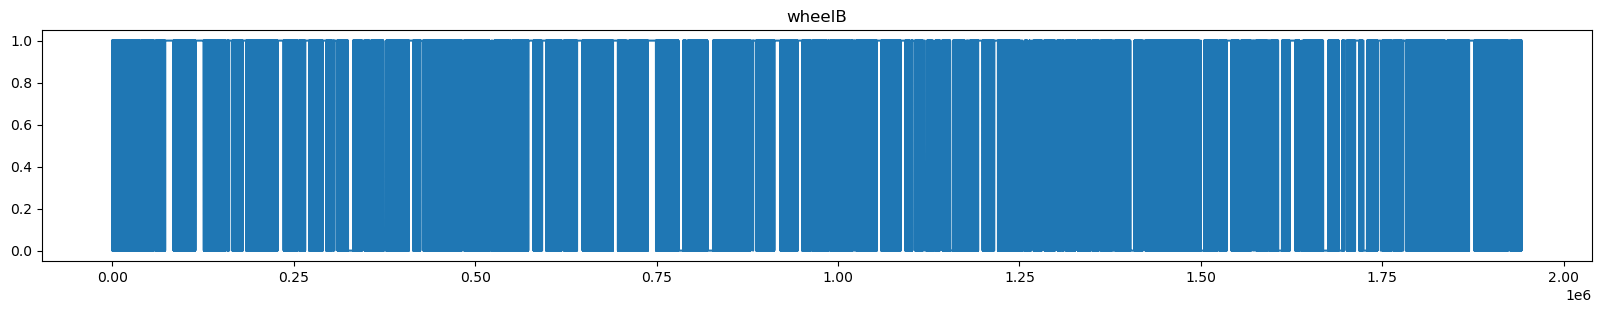

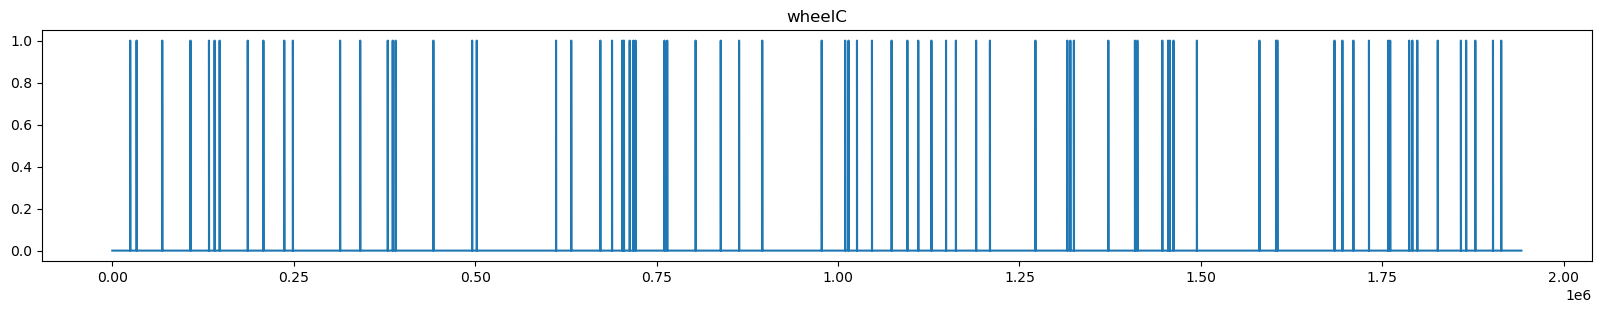

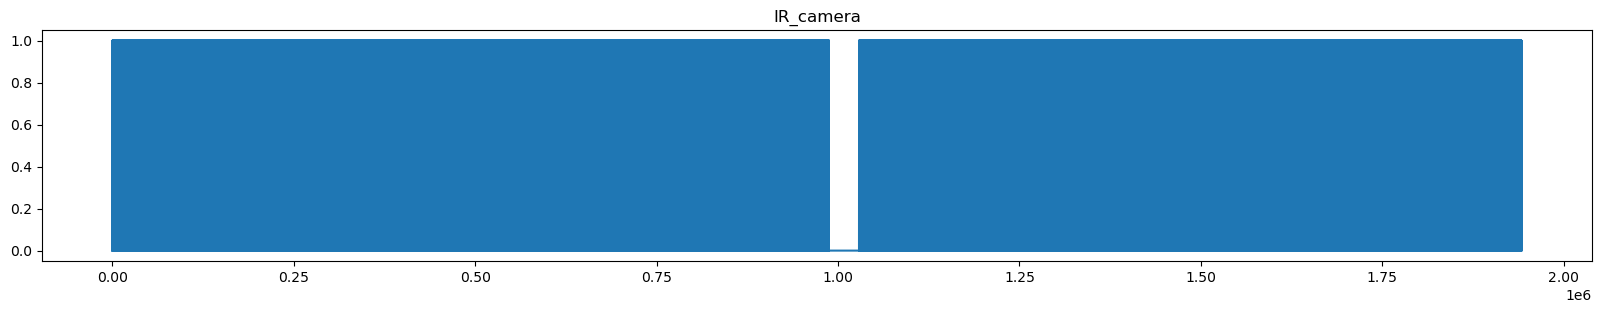

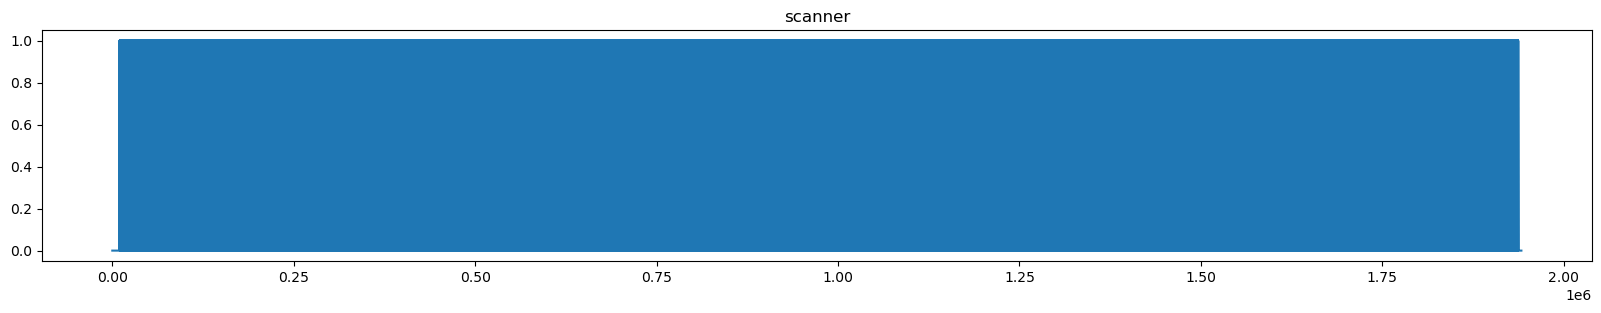

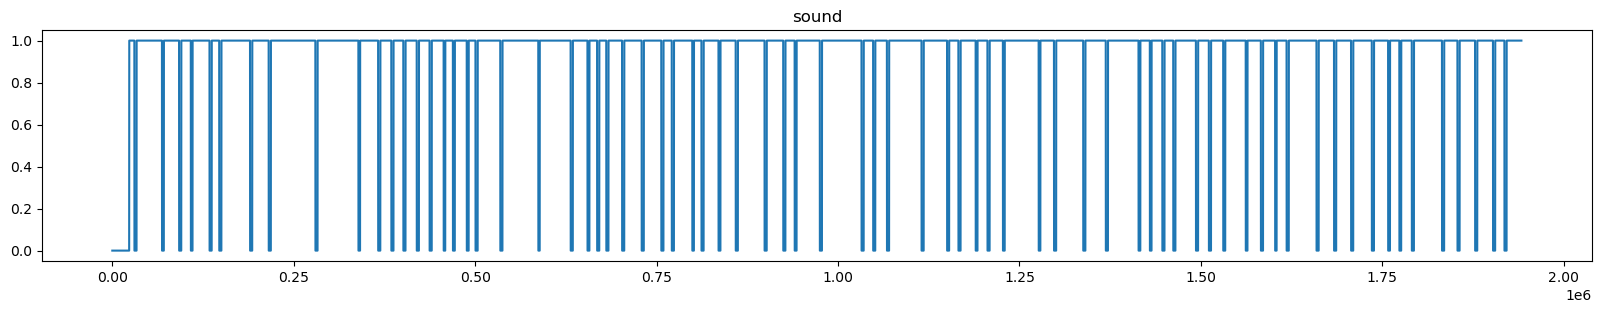

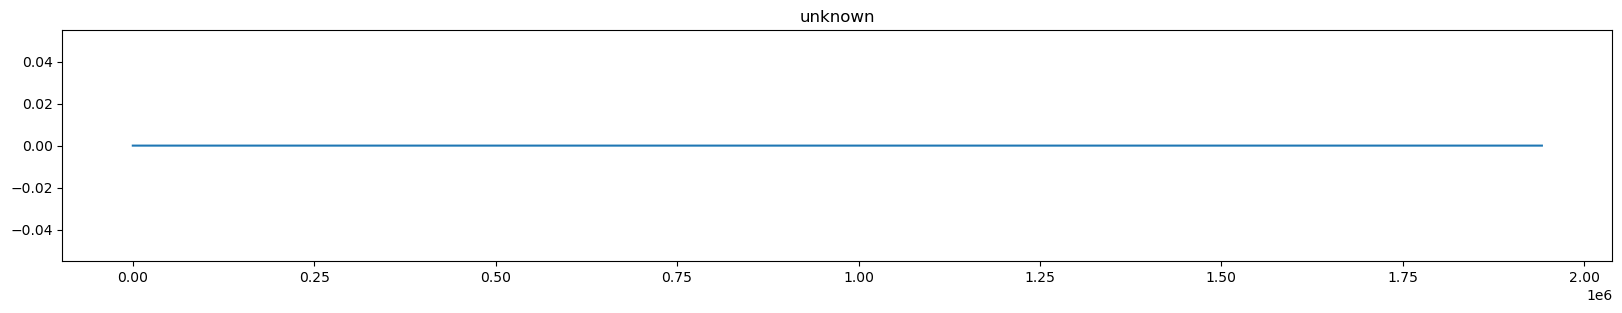

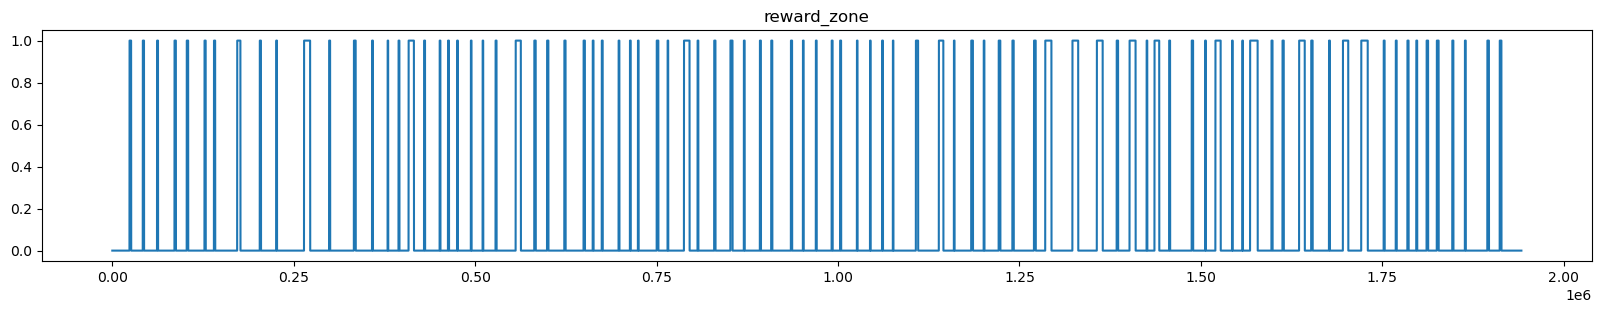

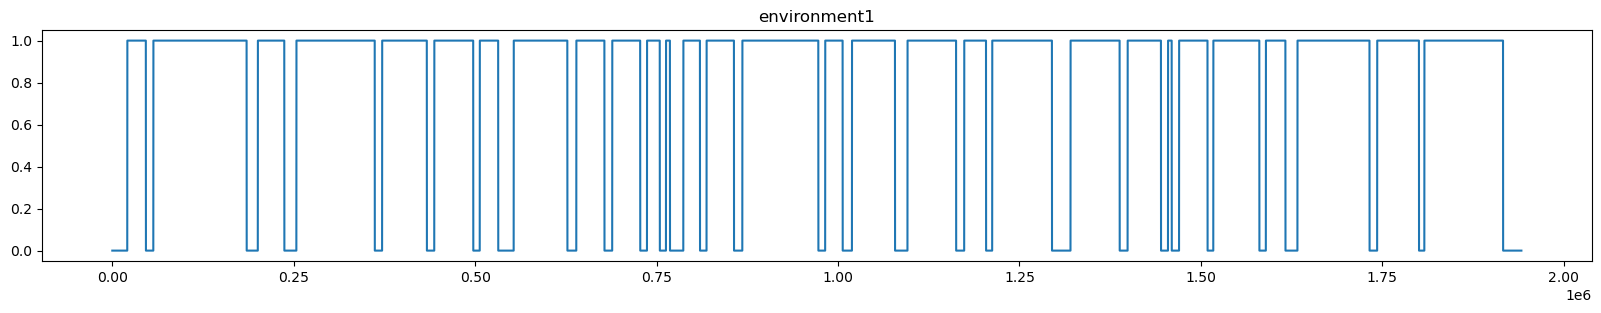

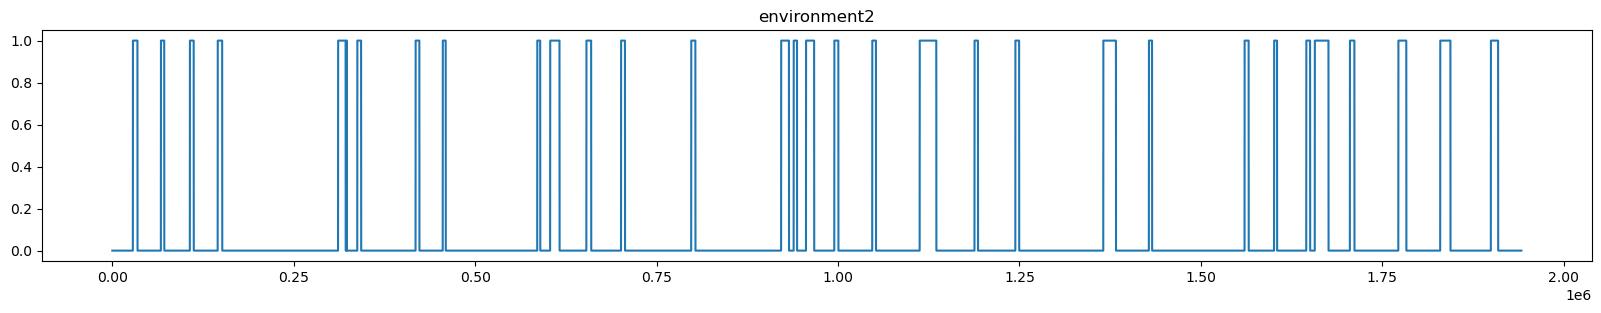

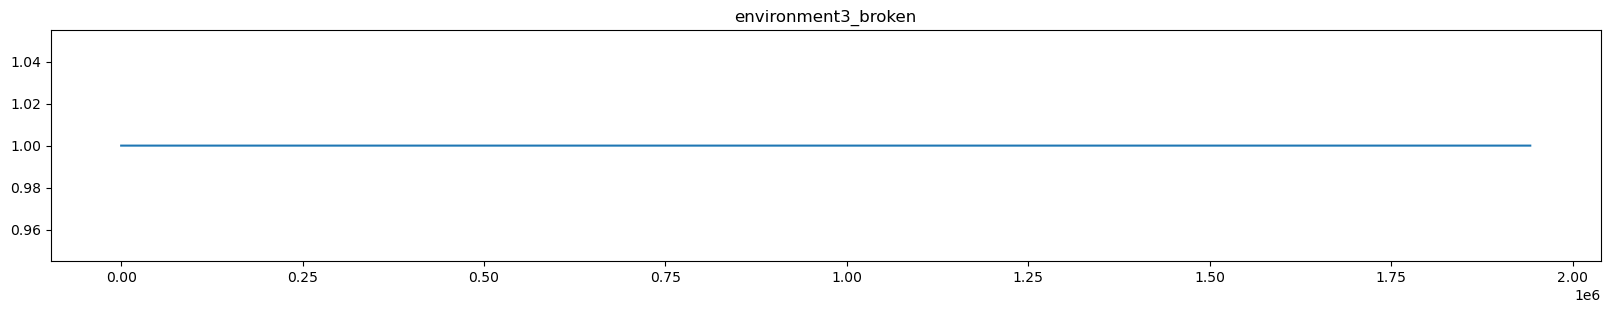

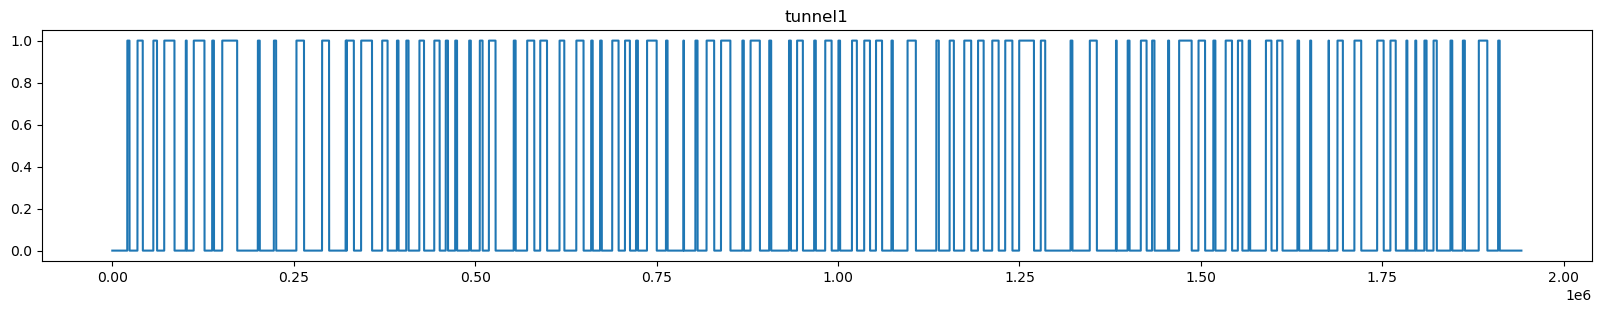

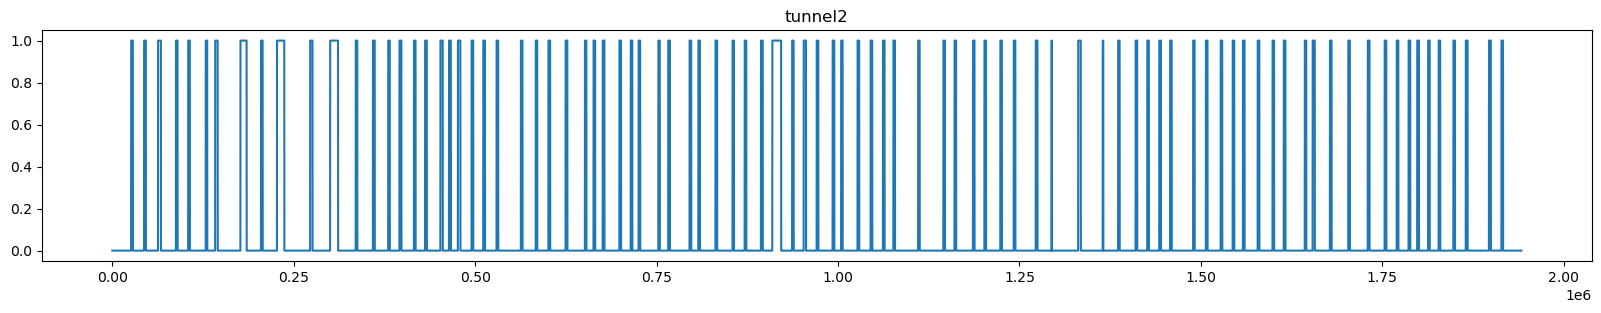

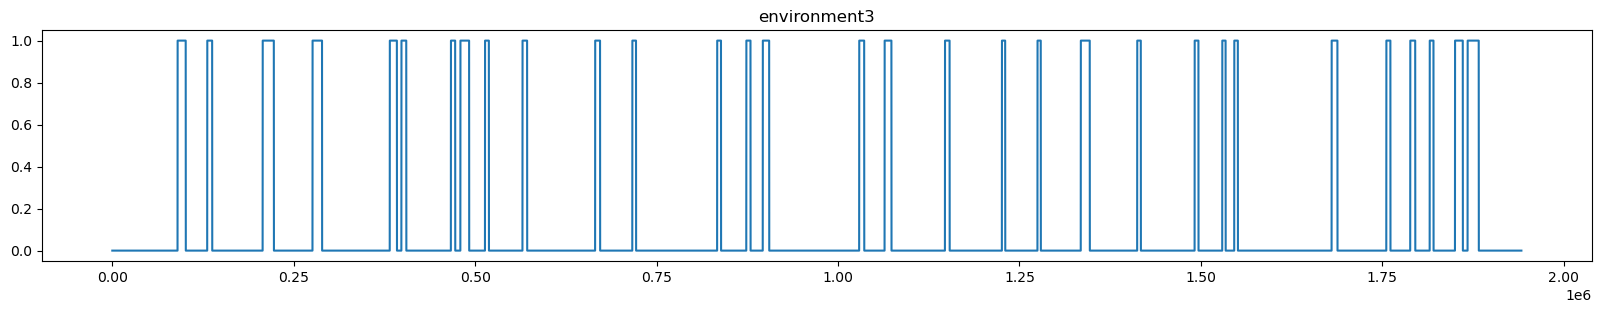

In [17]:
# plot all channels
for i,l in enumerate(labels_in):
    plt.figure(figsize=(20,3))
    plt.title(f'{l}')
    plt.plot(digital_in[:,i])

IndexError: index 8 is out of bounds for axis 1 with size 8

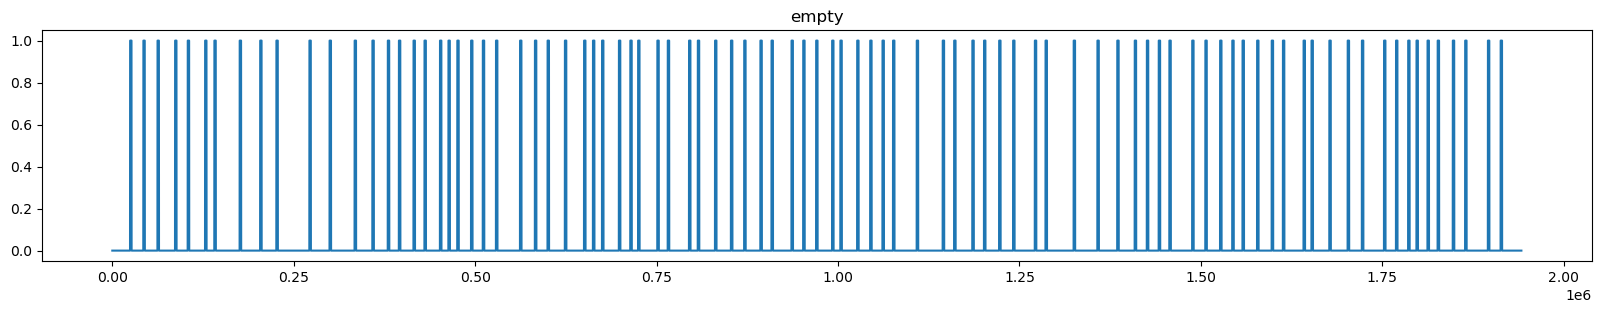

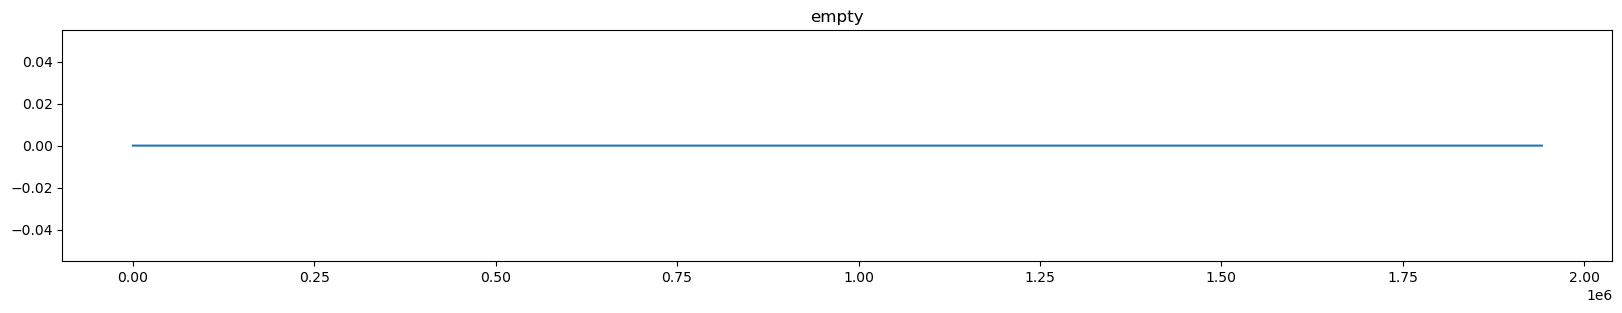

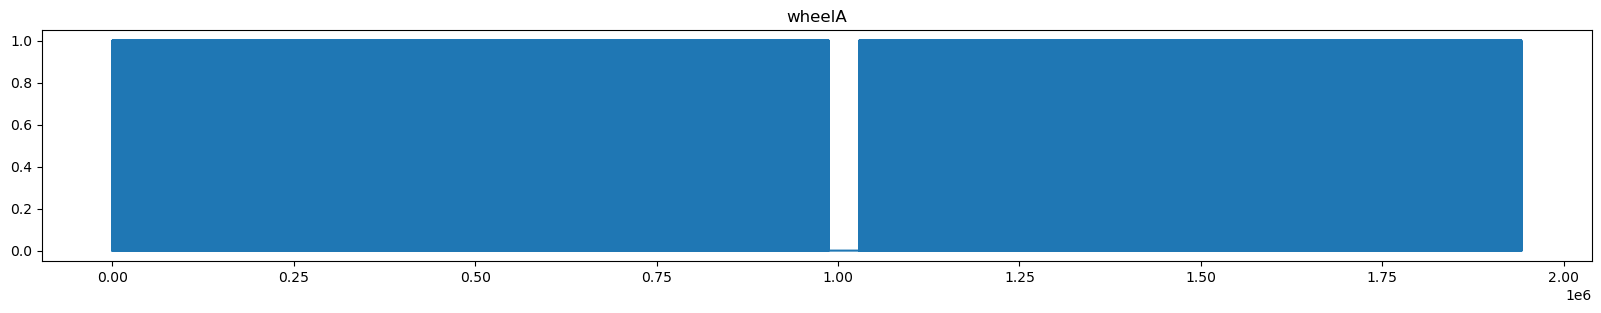

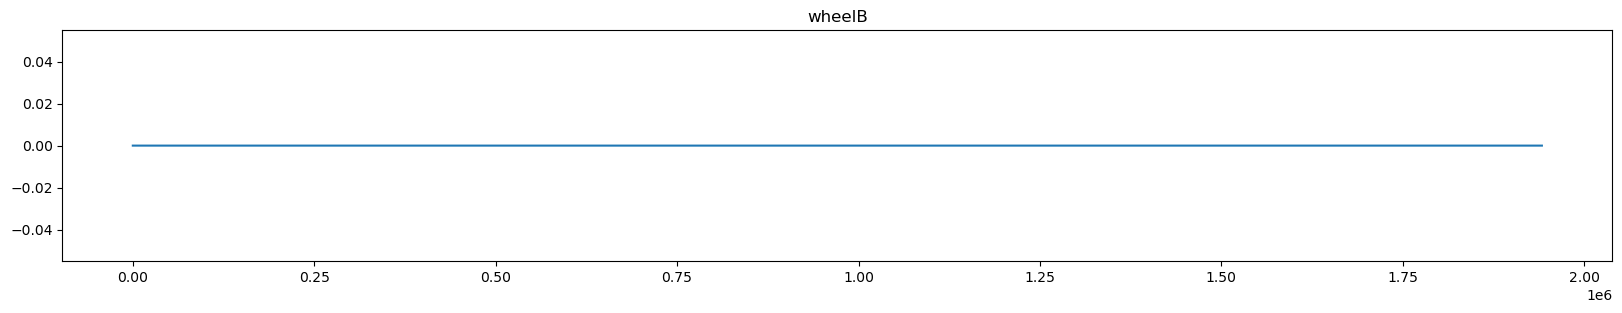

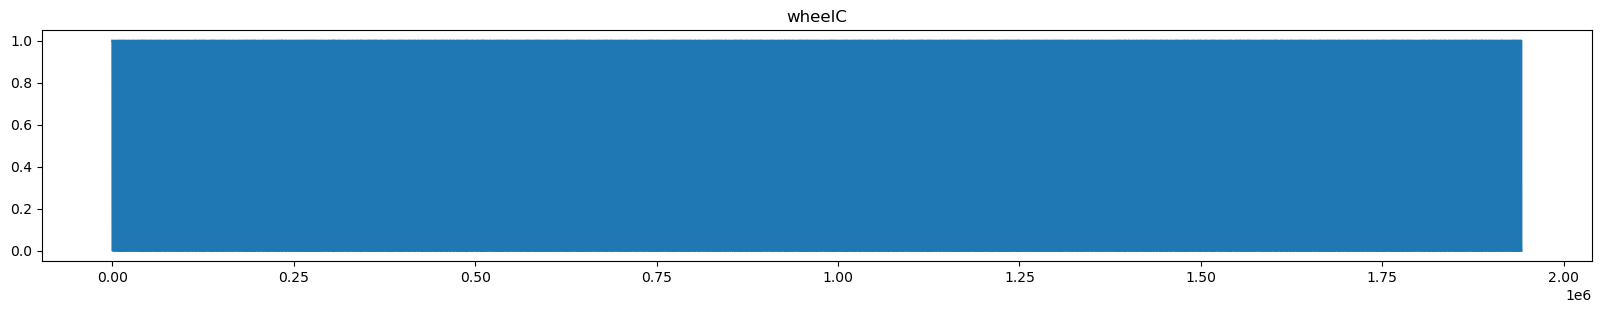

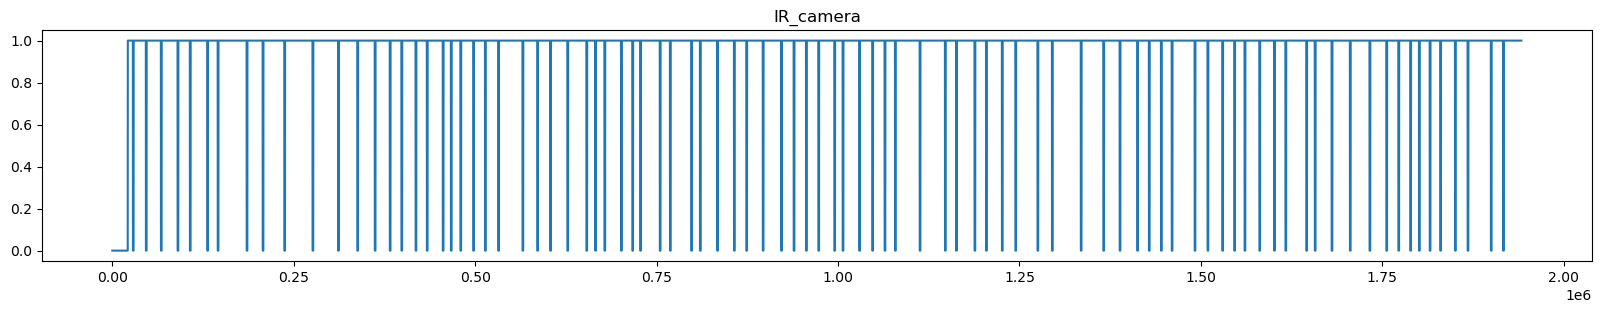

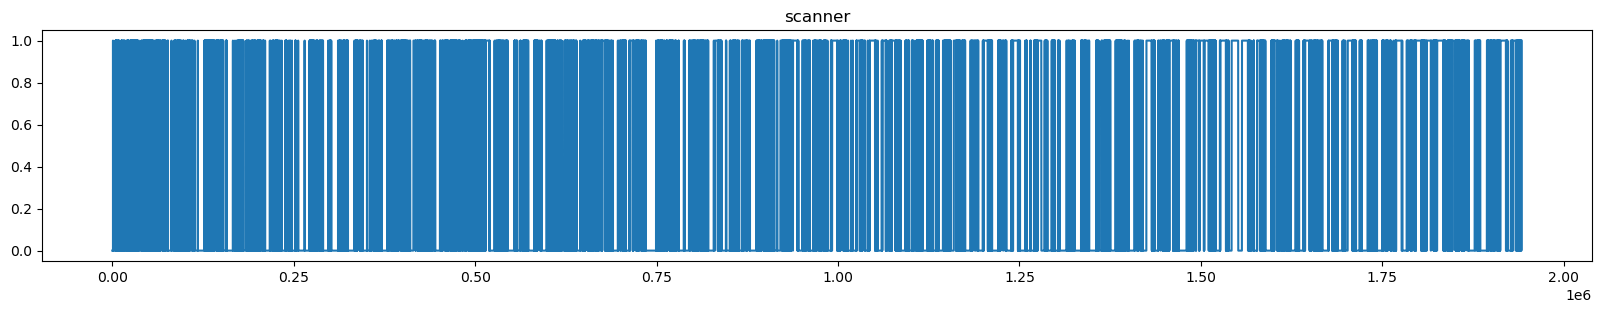

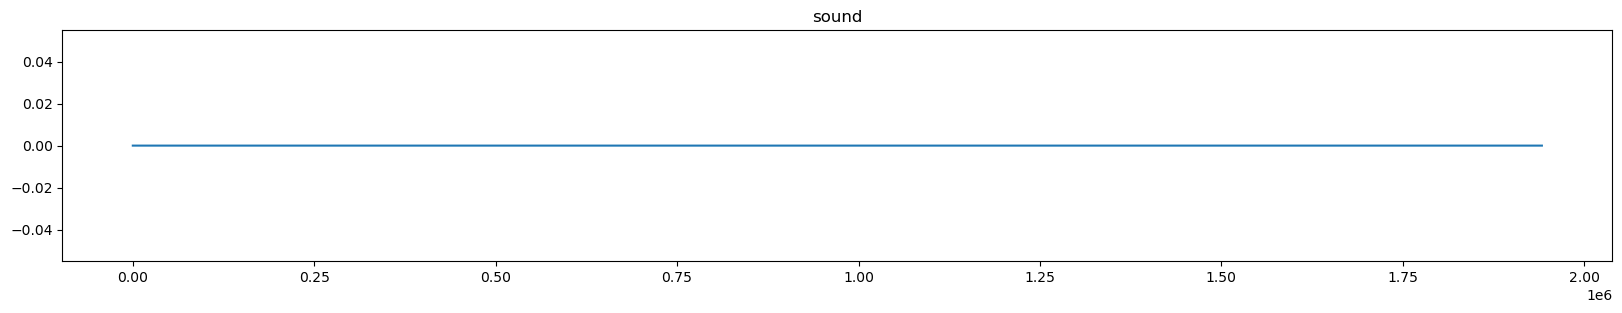

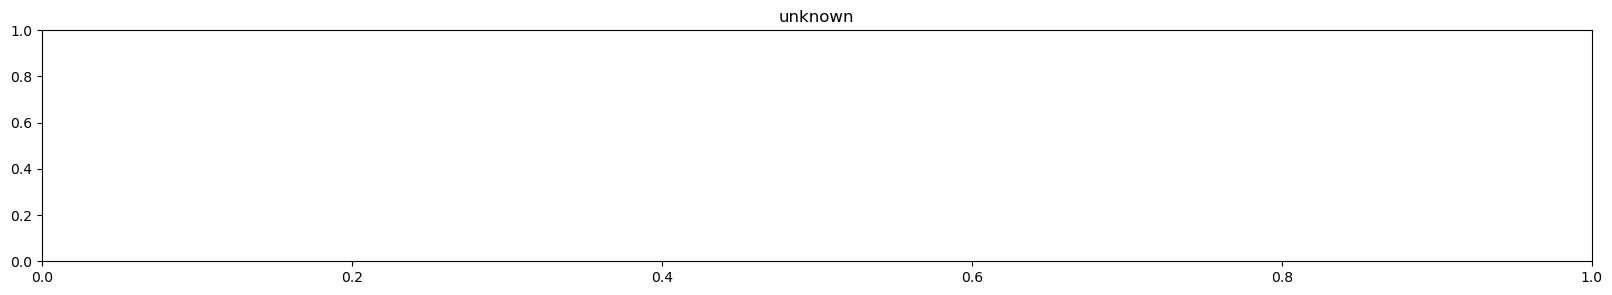

In [18]:
# plot all channels
for i,l in enumerate(labels_in):
    plt.figure(figsize=(20,3))
    plt.title(f'{l}')
    plt.plot(digital_out[:,i])